In [19]:
import numpy as np
import pandas as pd

from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
embeddings_dir = "/home/earkfeld/Projects/MitoSpace4D/runs/dhruv_files/embeddings_v2_data"

embeddings = np.load(f"{embeddings_dir}/embeddings.npy")
img_paths = np.load(f"{embeddings_dir}/image_paths.npy").tolist()
labels = np.load(f"{embeddings_dir}/labels.npy")
label_names = np.load(f"{embeddings_dir}/label_names.npy")

# Split embeddings into a list along first axis
embeddings = [embeddings[i] for i in range(embeddings.shape[0])]

df_data = pd.DataFrame({"image_paths": img_paths, "labels": labels, "embedding": embeddings})
df_metadata = pd.read_csv("/home/earkfeld/Projects/MitoSpace4D/experiments/temporal_phate/2024v2_metadata/2024v2_phate_metadata.csv")

In [4]:
df_data['drug'] = df_data['labels'].apply(lambda x: label_names[x])
df_data['image_paths'] = df_data['image_paths'].apply(lambda x: x.split('_data/')[-1])
df_data['region id'] = -1

In [5]:
df_data.head()

,image_paths,labels,embedding,drug,region id
0,20240904-1/000029-0.npy,20,"[[0.028739166, -0.0107329665, -0.014232904, 0....",tiron,-1
1,20240816-1/002168-0.npy,13,"[[0.0035427993, -0.0030259765, -0.005611732, 0...",mitomycinc,-1
2,20240830-1/000161-0.npy,18,"[[0.02747593, -0.0015405272, -0.016505742, 0.0...",colchicine,-1
3,20240910-1/000387-0.npy,22,"[[0.030882351, -0.0054568998, -0.0032086708, 0...",rotenone,-1
4,20240801-1/000995-0.npy,3,"[[0.037068617, 0.003085326, -0.019605407, 0.05...",mfi8,-1


In [6]:
df_metadata.head()

,sample id,region id,cell id,movie id,global_start_frame,path
0,20240729-1,0,0,0,0,20240729-1/000000-0.npy
1,20240729-1,0,1,0,0,20240729-1/000001-0.npy
2,20240729-1,0,2,0,0,20240729-1/000002-0.npy
3,20240729-1,0,3,0,0,20240729-1/000003-0.npy
4,20240729-1,0,4,0,0,20240729-1/000004-0.npy


In [7]:
# set the region id in df_data based on matching image paths in df_metadata
for idx, row in df_metadata.iterrows():
    img_path = row['path']
    df_data.loc[df_data['image_paths'] == img_path, 'region id'] = row['region id']
    df_data.loc[df_data['image_paths'] == img_path, 'movie id'] = int(row['movie id'])

In [8]:
df_data.head()

,image_paths,labels,embedding,drug,region id,movie id
0,20240904-1/000029-0.npy,20,"[[0.028739166, -0.0107329665, -0.014232904, 0....",tiron,0,0.0
1,20240816-1/002168-0.npy,13,"[[0.0035427993, -0.0030259765, -0.005611732, 0...",mitomycinc,9,0.0
2,20240830-1/000161-0.npy,18,"[[0.02747593, -0.0015405272, -0.016505742, 0.0...",colchicine,0,0.0
3,20240910-1/000387-0.npy,22,"[[0.030882351, -0.0054568998, -0.0032086708, 0...",rotenone,2,0.0
4,20240801-1/000995-0.npy,3,"[[0.037068617, 0.003085326, -0.019605407, 0.05...",mfi8,6,0.0


In [9]:
df_data['embedding'][0].shape

(20, 2048)

In [82]:
# # Average last frame per movie id per region per condition and stack regions for per-condition trajectories
# phate_data = []
# for lbl in np.unique(labels):
#     label_name = label_names[lbl]
#     df_condition = df_data[df_data['labels'] == lbl].reset_index(drop=True)
#     regions = df_condition['region id'].unique()
#     for region in regions:
#         df_region = df_condition[df_condition['region id'] == region].reset_index(drop=True)
#         movie_ids = df_region[df_region['region id'] == region]['movie id'].unique()
#         for movie_id in movie_ids:
#             df_movie = df_region[df_region['movie id'] == movie_id].reset_index(drop=True)
#
#             # Get the last frame of each movie
#             embeddings = np.stack(df_movie['embedding'])
#             print(embeddings.shape)
#             embeddings = embeddings[:, -1, :]
#             embeddings = np.mean(embeddings, axis=0)
#             time = (int(df_movie.at[0, 'region id'])+1) * 20
#             phate_data.append({"drug": label_name, "time": float(time), "embedding": embeddings})
# df_phate = pd.DataFrame(phate_data)

In [10]:
# Average per movie id per region per condition and stack regions for per-condition trajectories
phate_data = []
for lbl in np.unique(labels):
    label_name = label_names[lbl]
    df_condition = df_data[df_data['labels'] == lbl].reset_index(drop=True)
    regions = df_condition['region id'].unique()
    for region in regions:
        df_region = df_condition[df_condition['region id'] == region].reset_index(drop=True)
        movie_ids = df_region[df_region['region id'] == region]['movie id'].unique()
        for movie_id in movie_ids:
            df_movie = df_region[df_region['movie id'] == movie_id].reset_index(drop=True)

            print(np.array(df_movie['embedding']).shape)
            embeddings = np.mean(np.stack(df_movie['embedding'].to_list()), axis=0)
            print(embeddings.shape)

            t_start = int(df_movie.at[0, 'region id']) * 20
            for i in range(len(embeddings)):
                t = t_start + i
                phate_data.append({"drug": label_name, "time": float(t), "embedding": embeddings[i]})
df_phate = pd.DataFrame(phate_data)

(169,)
(20, 2048)
(194,)
(20, 2048)
(180,)
(20, 2048)
(226,)
(20, 2048)
(172,)
(20, 2048)
(152,)
(20, 2048)
(148,)
(20, 2048)
(150,)
(20, 2048)
(131,)
(20, 2048)
(187,)
(20, 2048)
(191,)
(20, 2048)
(213,)
(20, 2048)
(58,)
(20, 2048)
(68,)
(20, 2048)
(129,)
(20, 2048)
(124,)
(20, 2048)
(115,)
(20, 2048)
(189,)
(20, 2048)
(99,)
(20, 2048)
(114,)
(20, 2048)
(95,)
(20, 2048)
(110,)
(20, 2048)
(143,)
(20, 2048)
(111,)
(20, 2048)
(111,)
(20, 2048)
(111,)
(20, 2048)
(120,)
(20, 2048)
(130,)
(20, 2048)
(97,)
(20, 2048)
(182,)
(20, 2048)
(127,)
(20, 2048)
(213,)
(20, 2048)
(151,)
(20, 2048)
(131,)
(20, 2048)
(154,)
(20, 2048)
(142,)
(20, 2048)
(209,)
(20, 2048)
(151,)
(20, 2048)
(108,)
(20, 2048)
(133,)
(20, 2048)
(123,)
(20, 2048)
(148,)
(20, 2048)
(152,)
(20, 2048)
(123,)
(20, 2048)
(115,)
(20, 2048)
(110,)
(20, 2048)
(124,)
(20, 2048)
(136,)
(20, 2048)
(209,)
(20, 2048)
(178,)
(20, 2048)
(217,)
(20, 2048)
(199,)
(20, 2048)
(194,)
(20, 2048)
(163,)
(20, 2048)
(118,)
(20, 2048)
(168,)
(20, 204

In [64]:
df_movie.head()

,image_paths,labels,embedding,drug,region id,movie id


In [ ]:
# # Average per movie id per region per condition and stack regions for per-condition trajectories
# phate_data = []
#
# for lbl in np.unique(labels):
#     df_condition = metadata[metadata['label_id'] == lbl].reset_index(drop=True)
#     label_name = df_condition.at[0, 'label_name']
#     regions = df_condition['region id'].unique()
#     for region in regions:
#         df_region = df_condition[df_condition['region id'] == region].reset_index(drop=True)
#
#         movie_ids = df_region['movie id'].unique()
#         for movie_id in movie_ids:
#             df_movie = df_region[df_region['movie id'] == movie_id].reset_index(drop=True)
#             embeddings = np.mean(np.stack(df_movie['embedding'].to_list()), axis=0)
#
#             t_start = df_movie.at[0, 'global_start_frame']
#             for i in range(len(embeddings)):
#                 t = t_start + i
#                 phate_data.append({"drug": label_name, "time": float(t), "embedding": embeddings[i]})
#
# df_phate = pd.DataFrame(phate_data)

In [72]:
df_phate["embedding"][0].shape

(2048,)

In [11]:
# Save to parquet
df_phate.to_parquet("2024v2-embeddings_2024v1-model_phate_mean-pooled_per-frame.parquet", engine='pyarrow', index=False)

control


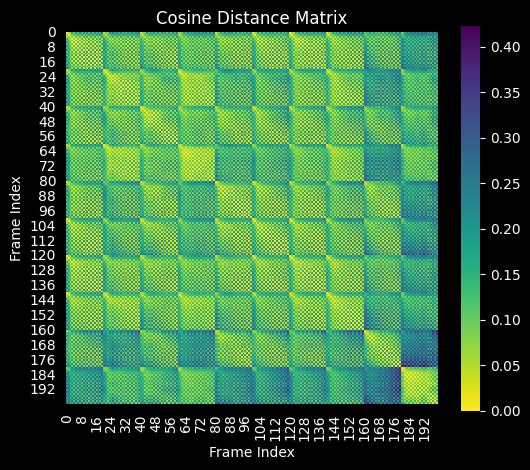

In [33]:
print(df_phate['drug'][0])
embeddings = np.stack(df_phate['embedding'][:200])

dists = cdist(embeddings, embeddings, metric='cosine')

# 3. Plot
plt.figure(figsize=(6, 5))
sns.heatmap(dists, cmap='viridis_r', square=True)
plt.title("Cosine Distance Matrix")
plt.xlabel("Frame Index")
plt.ylabel("Frame Index")
plt.show()

## Testing random stacking and averaging

In [28]:
embeddings_dir = "/mnt/aquila/others/Users/Eric/20260114_dhruv_embeddings_2024v1-model/resnetbilistm_encoder_consistent_temporal/embeddings"
embeddings = np.load(f"{embeddings_dir}/embeddings.npy")
print(embeddings.shape)

(34145, 20, 2048)


In [33]:
seed = 1123
np.random.seed(seed)
np.random.shuffle(embeddings)

shape_factor = 5
reshape_embeddings = embeddings.reshape(embeddings.shape[0]//shape_factor, shape_factor*embeddings.shape[1], embeddings.shape[-1])

In [34]:
reshape_embeddings = np.mean(reshape_embeddings, axis=0)
reshape_embeddings.shape

(100, 2048)

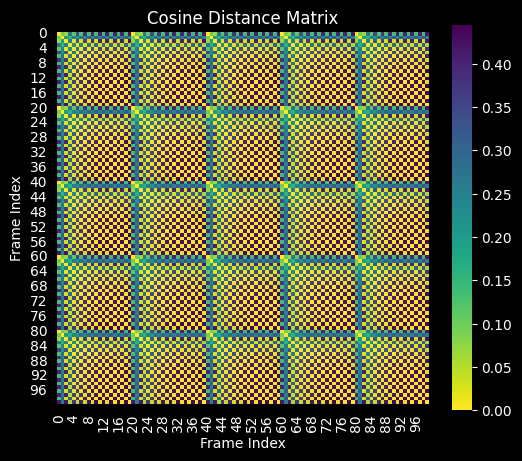

In [35]:
dists = cdist(reshape_embeddings, reshape_embeddings, metric='cosine')

# 3. Plot
plt.figure(figsize=(6, 5))
sns.heatmap(dists, cmap='viridis_r', square=True)
plt.title("Cosine Distance Matrix")
plt.xlabel("Frame Index")
plt.ylabel("Frame Index")
plt.show()

## Calculating distribution statistics across embeddings for the first frame of each movie

In [21]:
embeddings_dir = "/mnt/aquila/others/Users/Eric/20260114_dhruv_embeddings_2024v1-model/resnetbilistm_encoder_consistent_temporal/embeddings"
embeddings = np.load(f"{embeddings_dir}/embeddings.npy")

n_sample = 1000
seed = 1123
np.random.seed(seed)
np.random.shuffle(embeddings)
embeddings = embeddings[:n_sample]

In [22]:
first_frames = embeddings[:, 0, :]
last_frames = embeddings[:, -1, :]

In [23]:
first_frame_dists = cdist(first_frames, first_frames, metric='cosine')
last_frame_dists = cdist(last_frames, last_frames, metric='cosine')

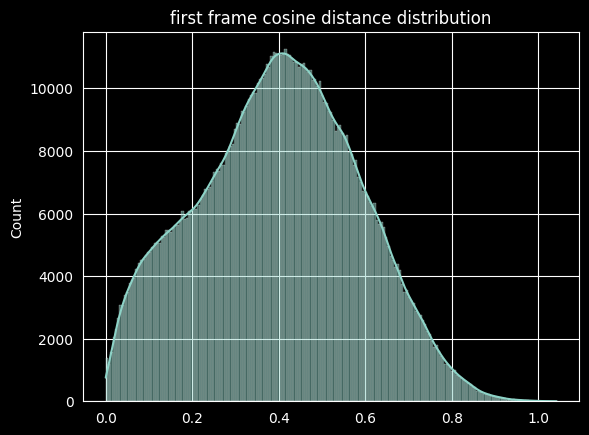

In [24]:
sns.histplot(first_frame_dists.flatten(), kde=True)
plt.title("first frame cosine distance distribution")
plt.show()

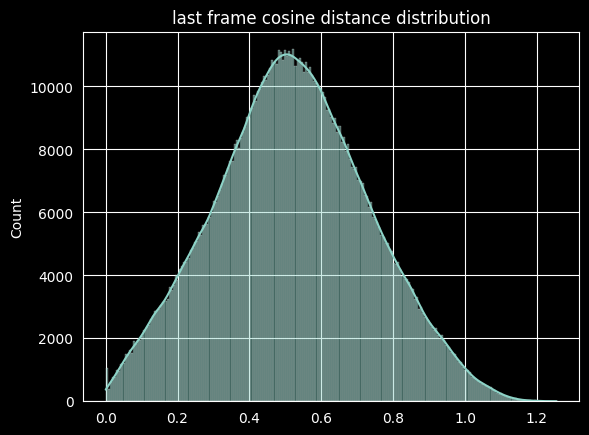

In [25]:
sns.histplot(last_frame_dists.flatten(), kde=True)
plt.title("last frame cosine distance distribution")
plt.show()

In [26]:
average_distances = []
std_distances = []
for frame in range(embeddings.shape[1]):
    frame_embeddings = embeddings[:, frame, :]
    frame_dists = cdist(frame_embeddings, frame_embeddings, metric='cosine')
    average_distances.append(np.mean(frame_dists))
    std_distances.append(np.std(frame_dists))

Text(0.5, 1.0, 'Average Cosine Distance Over Frames (n=1000 random samples)')

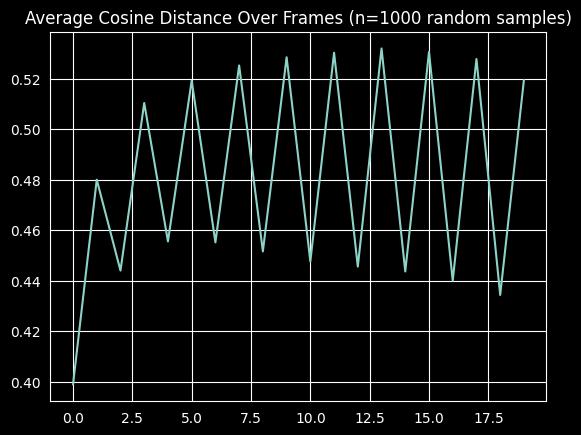

In [27]:
# simple line plot of average distances over frames
sns.lineplot(x=list(range(embeddings.shape[1])), y=average_distances)
plt.title("Average Cosine Distance Over Frames (n=1000 random samples)")